# M2A4 - Divisão de Dados

> **Resumo:** Dados são o combustível do ML. Aqui aprendemos a dividir corretamente em treino/validação/teste e usamos validação cruzada pra resultados mais confiáveis.

> 📝 **Regra de ouro:** Os conjuntos de treino, validação e teste são DISJUNTOS. Contaminação = resultados mentirosos!

**Estrutura do notebook:**

- Conceitos (treino/val/teste, vieses, contaminação)
- Prática com scikit-learn
- Validação Cruzada
- ✅ Atividades Complementares

## Conceitos

### Por que dividir?
- **Treino (80%):** onde o modelo aprende
- **Validação (15%):** pra ajustar hiperparâmetros (ex: o K do KNN)
- **Teste (5%):** avaliação final, simula o mundo real

### Cuidados
- **Viés:** se o dataset não representa o problema real, o modelo vai aprender errado
- **Contaminação:** se um dado aparece em treino E teste, o resultado é inválido

## Prática

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
# Carregar dataset
digits = datasets.load_digits()
X, y = digits.data, digits.target

print(f"Total de amostras: {len(X)}")
print(f"Features por amostra: {X.shape[1]}")

Total de amostras: 1797
Features por amostra: 64


### Train/Test Split básico

Treino: 1437 | Teste: 360
Distribuição de amostras por classe:
  - Classe 0: Treino = 142 | Teste = 36
  - Classe 1: Treino = 146 | Teste = 36
  - Classe 2: Treino = 142 | Teste = 35
  - Classe 3: Treino = 146 | Teste = 37
  - Classe 4: Treino = 145 | Teste = 36
  - Classe 5: Treino = 145 | Teste = 37
  - Classe 6: Treino = 145 | Teste = 36
  - Classe 7: Treino = 143 | Teste = 36
  - Classe 8: Treino = 139 | Teste = 35
  - Classe 9: Treino = 144 | Teste = 36


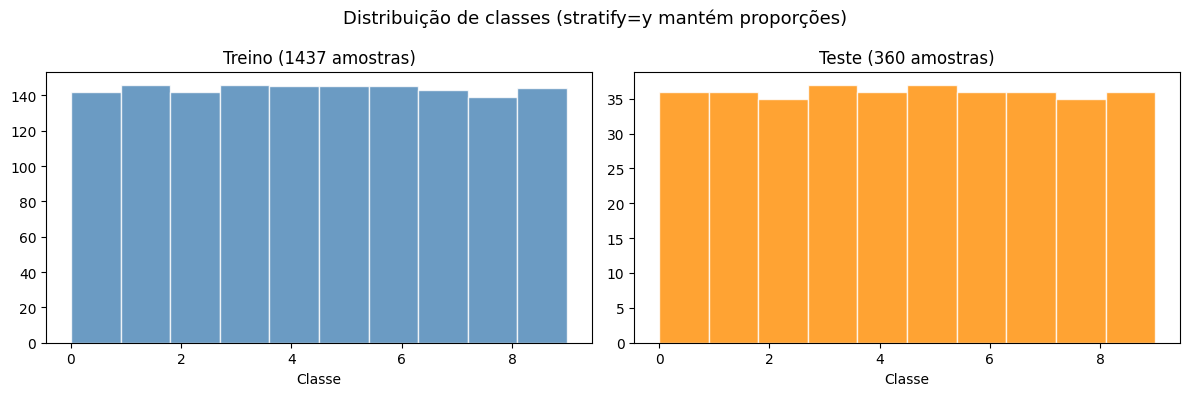

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")

# Contagem por classe
train_counts = np.bincount(y_train)
test_counts = np.bincount(y_test)
print("Distribuição de amostras por classe:")
for label in range(len(train_counts)):
    print(f"  - Classe {label}: Treino = {train_counts[label]} | Teste = {test_counts[label]}")


# Verificar distribuição das classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=10, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f"Treino ({len(X_train)} amostras)")
axes[0].set_xlabel("Classe")
axes[1].hist(y_test, bins=10, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].set_title(f"Teste ({len(X_test)} amostras)")
axes[1].set_xlabel("Classe")
plt.suptitle("Distribuição de classes (stratify=y mantém proporções)", fontsize=13)
plt.tight_layout()
plt.show()

> 📝 O `stratify=y` garante que treino e teste tenham a mesma proporção de cada classe. Sem isso, pode acontecer de uma classe ficar sub-representada no teste.

### Demonstrando contaminação de dados

In [4]:
# ERRADO: treinar e testar no MESMO conjunto
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)  # Treinando com TUDO
acc_contaminado = accuracy_score(y, knn.predict(X))  # Testando com TUDO

# CORRETO: conjuntos separados
knn2 = KNeighborsClassifier(n_neighbors=1)
knn2.fit(X_train, y_train)
acc_correto = accuracy_score(y_test, knn2.predict(X_test))

print(f"❌ Contaminado (treino=teste):  {acc_contaminado*100:.1f}% ← MENTIRA!")
print(f"✅ Correto (conjuntos separados): {acc_correto*100:.1f}% ← resultado real")

❌ Contaminado (treino=teste):  100.0% ← MENTIRA!
✅ Correto (conjuntos separados): 98.6% ← resultado real


> 📝 100% de acurácia? O KNN com K=1 simplesmente encontra a MESMA amostra no treino. Isso é decorar, não aprender!

### Validação Cruzada (K-Fold)

Em vez de confiar em uma única divisão treino/teste, dividimos em K partes e rodamos K vezes:

In [5]:
# Validação cruzada com 5 folds
knn = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')

print(f"Acurácias por fold: {[f'{s*100:.1f}%' for s in scores]}")
print(f"Média: {scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")

Acurácias por fold: ['94.7%', '95.6%', '96.7%', '98.1%', '96.4%']
Média: 96.3% ± 1.1%


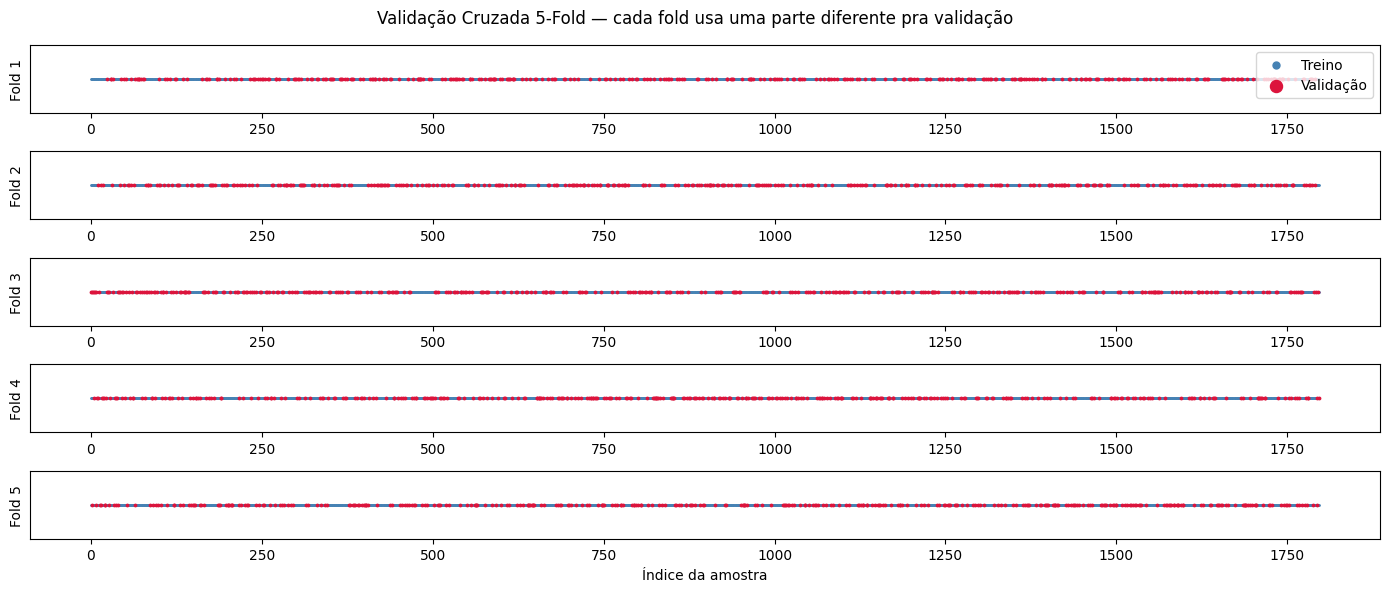

In [6]:
# Visualizar os folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(5, 1, figsize=(14, 6))
for i, (train_idx, val_idx) in enumerate(kf.split(X)):
    axes[i].scatter(train_idx, [0]*len(train_idx), c='steelblue', s=1, label='Treino')
    axes[i].scatter(val_idx, [0]*len(val_idx), c='crimson', s=3, label='Validação')
    axes[i].set_ylabel(f"Fold {i+1}")
    axes[i].set_yticks([])
    if i == 0:
        axes[i].legend(loc='upper right', markerscale=5)
axes[-1].set_xlabel("Índice da amostra")
plt.suptitle("Validação Cruzada 5-Fold — cada fold usa uma parte diferente pra validação", fontsize=12)
plt.tight_layout()
plt.show()

## ✅ Atividades Complementares

### Comparar modelos com validação cruzada

KNN (K=3)      : 96.7% ± 1.1%
KNN (K=7)      : 96.0% ± 1.5%
SVM (RBF)      : 96.3% ± 2.0%
Árvore         : 78.9% ± 3.7%


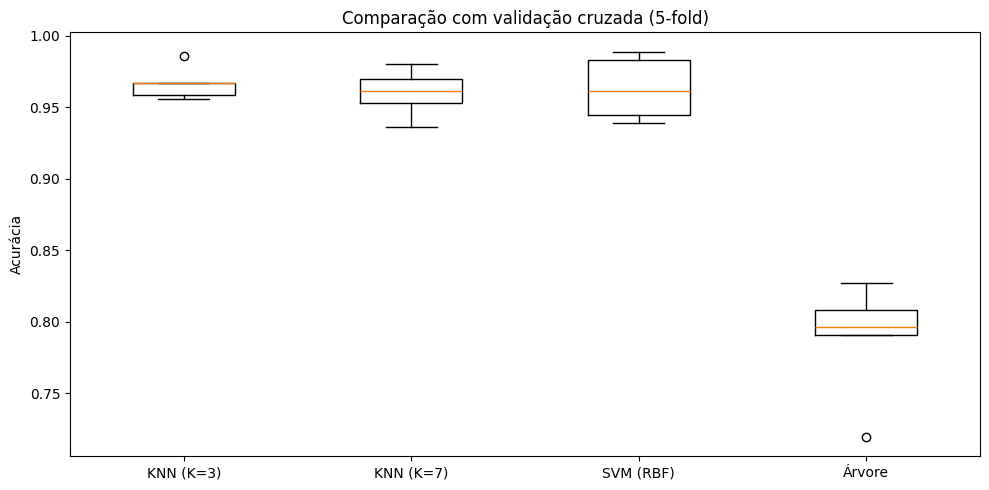

In [7]:
from sklearn.tree import DecisionTreeClassifier

models = {
    'KNN (K=3)': KNeighborsClassifier(n_neighbors=3),
    'KNN (K=7)': KNeighborsClassifier(n_neighbors=7),
    'SVM (RBF)': SVC(kernel='rbf'),
    'Árvore': DecisionTreeClassifier(random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    results[name] = scores
    print(f"{name:15s}: {scores.mean()*100:.1f}% ± {scores.std()*100:.1f}%")

# Boxplot
plt.figure(figsize=(10, 5))
plt.boxplot(results.values(), tick_labels=results.keys())

plt.ylabel("Acurácia")
plt.title("Comparação com validação cruzada (5-fold)")
plt.tight_layout()
plt.show()

> 📝 O boxplot mostra não só a média, mas a **variabilidade** entre folds. Um modelo bom tem acurácia alta E baixa variabilidade.